# Knn for classificaiton

In [22]:
import pandas as pd

data = pd.read_csv("../datasets/w3classif.csv", header=None, names=["x1", "x2", "y"])

In [23]:
# 数据探索和分析
print("数据集形状:", data.shape)
print("\n数据集前5行:")
print(data.head())
print("\n数据集基本信息:")
print(data.info())
print("\n数据集统计信息:")
print(data.describe())
print("\n类别分布:")
print(data["y"].value_counts())

数据集形状: (400, 3)

数据集前5行:
         x1        x2  y
0  0.475861  0.541139  0
1  1.412233 -1.540877  0
2  0.022608 -0.203143  0
3 -0.047869 -0.499965  0
4  1.701335  0.383024  0

数据集基本信息:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x1      400 non-null    float64
 1   x2      400 non-null    float64
 2   y       400 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 9.5 KB
None

数据集统计信息:
               x1          x2           y
count  400.000000  400.000000  400.000000
mean     1.504300    1.610388    0.500000
std      2.045366    2.071835    0.500626
min     -3.232038   -3.072989    0.000000
25%     -0.043643   -0.193087    0.000000
50%      1.084154    1.385823    0.500000
75%      3.105206    3.252946    1.000000
max      7.423639    7.095566    1.000000

类别分布:
y
0    200
1    200
Name: count, dtype: int64


唯一类别: [0 1]
类别 0 的数据点数量: 200
类别 1 的数据点数量: 200


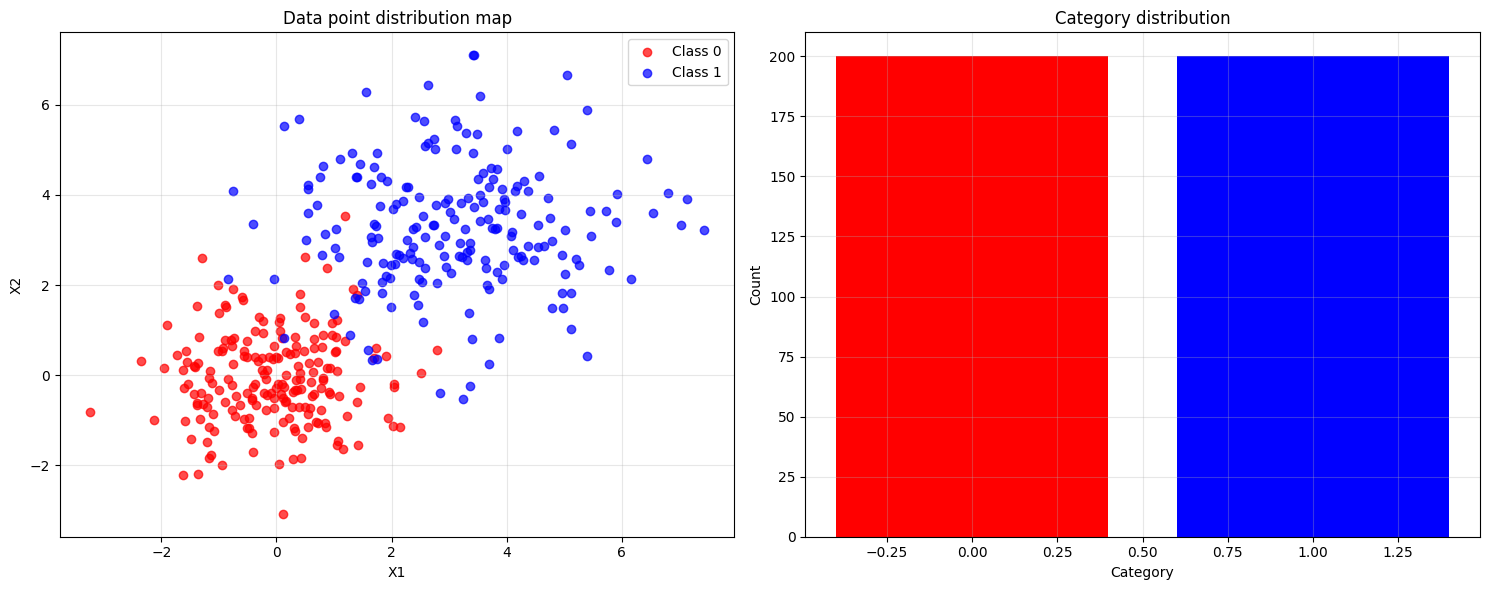

In [24]:
# 数据可视化
from matplotlib import pyplot as plt
import numpy as np
import seaborn as sns

# 创建subplot
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 散点图显示数据分布
colors = ["red", "blue", "green"]
unique_classes = data["y"].unique()
print("唯一类别:", unique_classes)
for i, class_label in enumerate(unique_classes):
    print(f"类别 {class_label} 的数据点数量:", len(data[data["y"] == class_label]))
    class_data = data[data["y"] == class_label]
    axes[0].scatter(
        class_data["x1"],
        class_data["x2"],
        c=colors[i],
        label=f"Class {class_label}",
        alpha=0.7,
    )

axes[0].set_xlabel("X1")
axes[0].set_ylabel("X2")
axes[0].set_title("Data point distribution map")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 类别分布柱状图
class_counts = data["y"].value_counts().sort_index()
axes[1].bar(class_counts.index, class_counts.values, color=["red", "blue", "green"])
axes[1].set_xlabel("Category")
axes[1].set_ylabel("Count")
axes[1].set_title("Category distribution")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [25]:
# 数据预处理
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Shuffle the data
data = data.sample(frac=1, random_state=42).reset_index(drop=True)

# 分离特征和标签
X = data[["x1", "x2"]].values
y = data["y"].values

print("特征矩阵 X 的形状:", X.shape)
print("标签向量 y 的形状:", y.shape)
print("特征矩阵 X 的前5行:")
print(X[:5])
print("标签向量 y 的前5个值:")
print(y[:5])

# 数据分割：训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n训练集大小: {X_train.shape[0]}")
print(f"测试集大小: {X_test.shape[0]}")

# 特征标准化
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n标准化前训练集特征统计:")
print("均值:", np.mean(X_train, axis=0))
print("标准差:", np.std(X_train, axis=0))

print("\n标准化后训练集特征统计:")
print("均值:", np.mean(X_train_scaled, axis=0))
print("标准差:", np.std(X_train_scaled, axis=0))

特征矩阵 X 的形状: (400, 2)
标签向量 y 的形状: (400,)
特征矩阵 X 的前5行:
[[ 3.54238075  3.43110048]
 [ 3.79120538  3.23513941]
 [ 0.34759263  0.6395173 ]
 [ 2.47216614  3.94935837]
 [-0.13447864  0.40918208]]
标签向量 y 的前5个值:
[1 1 0 1 0]

训练集大小: 320
测试集大小: 80

标准化前训练集特征统计:
均值: [1.50378732 1.60934721]
标准差: [2.04125716 2.06071322]

标准化后训练集特征统计:
均值: [-4.51028104e-17 -2.52228793e-16]
标准差: [1. 1.]


In [26]:
# KNN算法从零实现
from collections import Counter


class KNNClassifier:
    def __init__(self, k=3):
        """
        初始化KNN分类器

        参数:
        k: 邻居数量
        """
        self.k = k

    def fit(self, X_train, y_train):
        """
        训练KNN模型（实际上只是存储训练数据）

        参数:
        X_train: 训练特征
        y_train: 训练标签
        """
        self.X_train = X_train
        self.y_train = y_train
        print(f"KNN模型已训练，k={self.k}")
        print(f"训练数据包含 {len(X_train)} 个样本")

    def euclidean_distance(self, point1, point2):
        """
        计算两点间的欧几里得距离

        参数:
        point1, point2: 两个数据点

        返回:
        欧几里得距离
        """
        return np.sqrt(np.sum((point1 - point2) ** 2))

    def predict_single(self, x):
        """
        预测单个样本

        参数:
        x: 单个测试样本

        返回:
        预测的类别
        """
        # 计算测试点到所有训练点的距离
        distances = []
        for i in range(len(self.X_train)):
            dist = self.euclidean_distance(x, self.X_train[i])
            distances.append((dist, self.y_train[i]))

        # 按距离排序，选择k个最近的邻居
        distances.sort(key=lambda x: x[0])
        k_nearest = distances[: self.k]

        # 获取k个邻居的标签
        k_nearest_labels = [label for _, label in k_nearest]

        # 投票决定类别
        most_common = Counter(k_nearest_labels).most_common(1)
        return most_common[0][0]

    def predict(self, X_test):
        """
        预测多个样本

        参数:
        X_test: 测试特征

        返回:
        预测标签列表
        """
        predictions = []
        for i, x in enumerate(X_test):
            if i % 10 == 0:  # 每10个样本显示一次进度
                print(f"正在预测第 {i+1}/{len(X_test)} 个样本...")
            pred = self.predict_single(x)
            predictions.append(pred)
        return np.array(predictions)


# 创建KNN分类器实例
knn_custom = KNNClassifier(k=5)
knn_custom.fit(X_train_scaled, y_train)

KNN模型已训练，k=5
训练数据包含 320 个样本


开始预测...
正在预测第 1/80 个样本...
正在预测第 11/80 个样本...
正在预测第 21/80 个样本...
正在预测第 31/80 个样本...
正在预测第 41/80 个样本...
正在预测第 51/80 个样本...
正在预测第 41/80 个样本...
正在预测第 51/80 个样本...
正在预测第 61/80 个样本...
正在预测第 71/80 个样本...
正在预测第 61/80 个样本...
正在预测第 71/80 个样本...

自定义KNN准确率: 0.9375

分类报告:
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        40
           1       0.93      0.95      0.94        40

    accuracy                           0.94        80
   macro avg       0.94      0.94      0.94        80
weighted avg       0.94      0.94      0.94        80


混淆矩阵:
[[37  3]
 [ 2 38]]

自定义KNN准确率: 0.9375

分类报告:
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        40
           1       0.93      0.95      0.94        40

    accuracy                           0.94        80
   macro avg       0.94      0.94      0.94        80
weighted avg       0.94      0.94      0.94        80


混淆矩阵:
[[37  3]
 [ 2 38]]


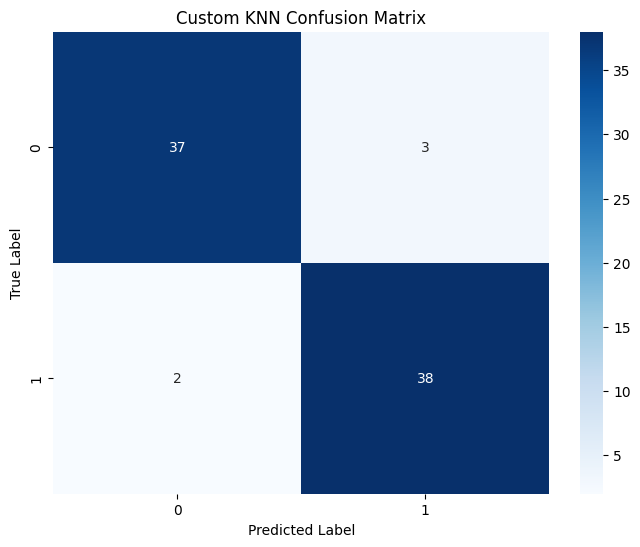

In [27]:
# 使用自定义KNN进行预测
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("开始预测...")
y_pred_custom = knn_custom.predict(X_test_scaled)

# 计算准确率
accuracy_custom = accuracy_score(y_test, y_pred_custom)
print(f"\n自定义KNN准确率: {accuracy_custom:.4f}")

# 详细评估报告
print("\n分类报告:")
print(classification_report(y_test, y_pred_custom))

# 混淆矩阵
conf_matrix = confusion_matrix(y_test, y_pred_custom)
print("\n混淆矩阵:")
print(conf_matrix)

# 可视化混淆矩阵
plt.figure(figsize=(8, 6))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=np.unique(y),
    yticklabels=np.unique(y),
)
plt.title("Custom KNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [28]:
# 使用scikit-learn的KNN进行对比
from sklearn.neighbors import KNeighborsClassifier

# 创建sklearn的KNN分类器
knn_sklearn = KNeighborsClassifier(n_neighbors=5)

# 训练模型
knn_sklearn.fit(X_train_scaled, y_train)

# 预测
y_pred_sklearn = knn_sklearn.predict(X_test_scaled)

# 计算准确率
accuracy_sklearn = accuracy_score(y_test, y_pred_sklearn)
print(f"Scikit-learn KNN准确率: {accuracy_sklearn:.4f}")

# 比较两种实现的结果
print(f"\n结果对比:")
print(f"自定义KNN准确率: {accuracy_custom:.4f}")
print(f"Scikit-learn KNN准确率: {accuracy_sklearn:.4f}")
print(f"预测结果是否一致: {np.array_equal(y_pred_custom, y_pred_sklearn)}")

# 如果结果不一致，显示差异
if not np.array_equal(y_pred_custom, y_pred_sklearn):
    diff_indices = np.where(y_pred_custom != y_pred_sklearn)[0]
    print(f"不一致的预测数量: {len(diff_indices)}")
    if len(diff_indices) > 0:
        print("前几个不一致的样本:")
        for i in diff_indices[:5]:
            print(
                f"样本 {i}: 自定义={y_pred_custom[i]}, sklearn={y_pred_sklearn[i]}, 真实={y_test[i]}"
            )

Scikit-learn KNN准确率: 0.9375

结果对比:
自定义KNN准确率: 0.9375
Scikit-learn KNN准确率: 0.9375
预测结果是否一致: True


正在测试不同的k值...
k=1: 交叉验证准确率 = 0.9437 (±0.0468)
k=2: 交叉验证准确率 = 0.9469 (±0.0508)
k=3: 交叉验证准确率 = 0.9594 (±0.0319)
k=4: 交叉验证准确率 = 0.9563 (±0.0364)
k=5: 交叉验证准确率 = 0.9563 (±0.0364)
k=1: 交叉验证准确率 = 0.9437 (±0.0468)
k=2: 交叉验证准确率 = 0.9469 (±0.0508)
k=3: 交叉验证准确率 = 0.9594 (±0.0319)
k=4: 交叉验证准确率 = 0.9563 (±0.0364)
k=5: 交叉验证准确率 = 0.9563 (±0.0364)
k=6: 交叉验证准确率 = 0.9563 (±0.0364)
k=6: 交叉验证准确率 = 0.9563 (±0.0364)
k=7: 交叉验证准确率 = 0.9531 (±0.0442)
k=8: 交叉验证准确率 = 0.9625 (±0.0319)
k=9: 交叉验证准确率 = 0.9625 (±0.0319)
k=10: 交叉验证准确率 = 0.9625 (±0.0319)
k=11: 交叉验证准确率 = 0.9625 (±0.0319)
k=7: 交叉验证准确率 = 0.9531 (±0.0442)
k=8: 交叉验证准确率 = 0.9625 (±0.0319)
k=9: 交叉验证准确率 = 0.9625 (±0.0319)
k=10: 交叉验证准确率 = 0.9625 (±0.0319)
k=11: 交叉验证准确率 = 0.9625 (±0.0319)
k=12: 交叉验证准确率 = 0.9625 (±0.0319)
k=12: 交叉验证准确率 = 0.9625 (±0.0319)
k=13: 交叉验证准确率 = 0.9656 (±0.0234)
k=14: 交叉验证准确率 = 0.9594 (±0.0319)
k=15: 交叉验证准确率 = 0.9625 (±0.0250)
k=16: 交叉验证准确率 = 0.9625 (±0.0250)
k=17: 交叉验证准确率 = 0.9656 (±0.0234)
k=13: 交叉验证准确率 = 0.9656 (±0.0234)
k=14: 交叉验证准确率 =

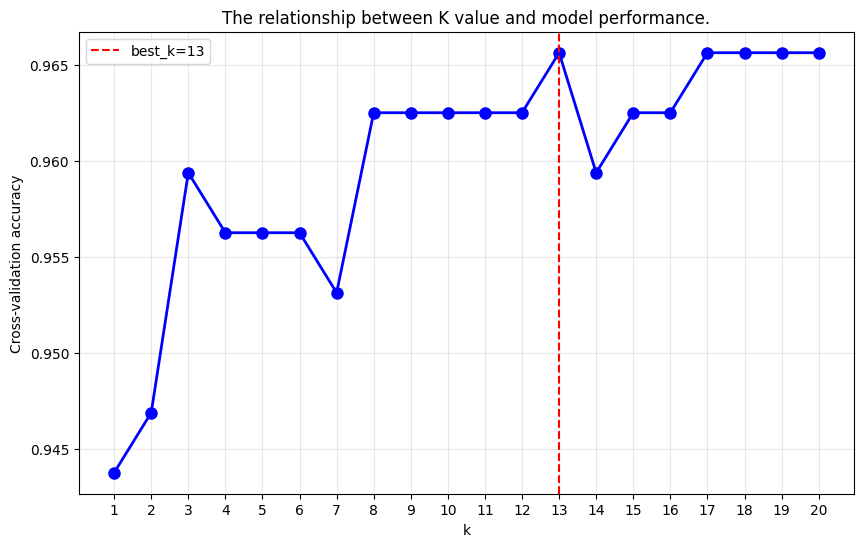

In [29]:
# K值优化 - 寻找最佳k值
from sklearn.model_selection import cross_val_score

# 测试不同的k值
k_values = range(1, 21)
cv_scores = []

print("正在测试不同的k值...")
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    # 使用5折交叉验证
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring="accuracy")
    cv_scores.append(scores.mean())
    print(f"k={k}: 交叉验证准确率 = {scores.mean():.4f} (±{scores.std()*2:.4f})")

# 找到最佳k值
best_k = k_values[np.argmax(cv_scores)]
best_score = max(cv_scores)
print(f"\n最佳k值: {best_k}, 最佳交叉验证准确率: {best_score:.4f}")

# 可视化k值与准确率的关系
plt.figure(figsize=(10, 6))
plt.plot(k_values, cv_scores, "bo-", linewidth=2, markersize=8)
plt.axvline(x=best_k, color="red", linestyle="--", label=f"best_k={best_k}")
plt.xlabel("k")
plt.ylabel("Cross-validation accuracy")
plt.title("The relationship between K value and model performance.")
plt.grid(True, alpha=0.3)
plt.legend()
plt.xticks(k_values)
plt.show()

In [30]:
# 使用最佳k值训练最终模型
final_knn = KNeighborsClassifier(n_neighbors=best_k)
final_knn.fit(X_train_scaled, y_train)

# 最终预测
y_pred_final = final_knn.predict(X_test_scaled)
final_accuracy = accuracy_score(y_test, y_pred_final)

print(f"最终模型 (k={best_k}) 在测试集上的准确率: {final_accuracy:.4f}")
print("\n最终模型分类报告:")
print(classification_report(y_test, y_pred_final))

# 预测概率
y_proba = final_knn.predict_proba(X_test_scaled)
print("\n前5个测试样本的预测概率:")
class_names = final_knn.classes_
for i in range(min(5, len(X_test_scaled))):
    print(f"样本 {i+1}:")
    for j, class_name in enumerate(class_names):
        print(f"  类别 {class_name}: {y_proba[i, j]:.4f}")
    print(f"  预测类别: {y_pred_final[i]}, 真实类别: {y_test[i]}")
    print()

最终模型 (k=13) 在测试集上的准确率: 0.9375

最终模型分类报告:
              precision    recall  f1-score   support

           0       0.93      0.95      0.94        40
           1       0.95      0.93      0.94        40

    accuracy                           0.94        80
   macro avg       0.94      0.94      0.94        80
weighted avg       0.94      0.94      0.94        80


前5个测试样本的预测概率:
样本 1:
  类别 0: 0.3077
  类别 1: 0.6923
  预测类别: 1, 真实类别: 0

样本 2:
  类别 0: 0.0000
  类别 1: 1.0000
  预测类别: 1, 真实类别: 1

样本 3:
  类别 0: 0.0000
  类别 1: 1.0000
  预测类别: 1, 真实类别: 1

样本 4:
  类别 0: 1.0000
  类别 1: 0.0000
  预测类别: 0, 真实类别: 0

样本 5:
  类别 0: 1.0000
  类别 1: 0.0000
  预测类别: 0, 真实类别: 0



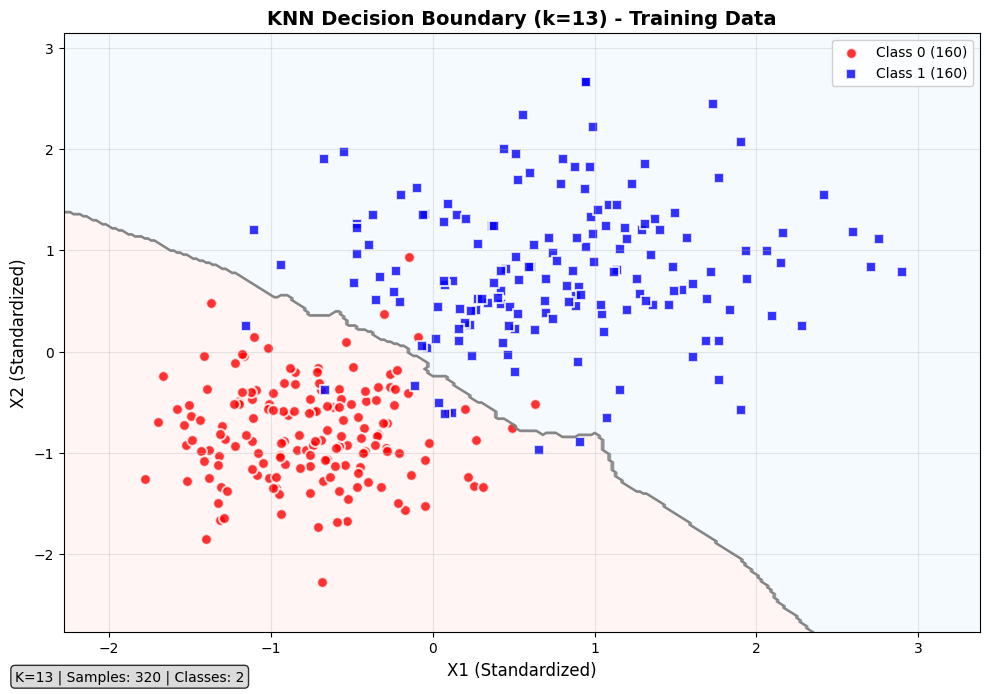

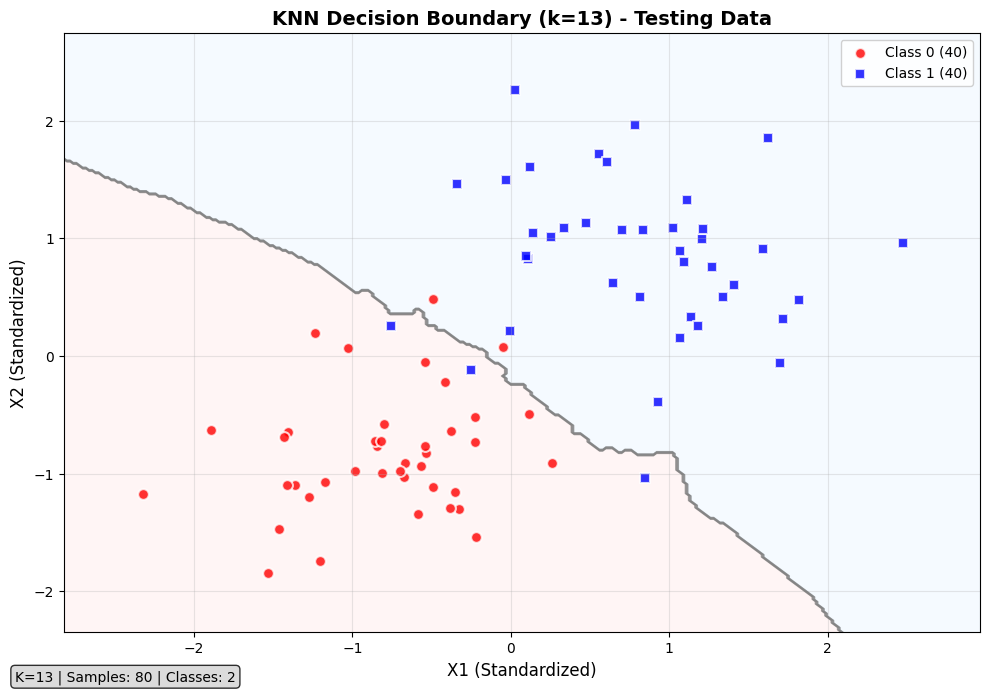

In [31]:
def plot_decision_boundary(X, y, classifier, title, h=0.02):
    """
        绘制分类器决策边界

    参数：

    X:  特征数据

    y:  标签数据

    classifier:  训练好的分类器

    title:  图表标题

    h:  网格步长
    """
    # 创建具有较小边距的网格。
    margin = 0.5
    x_min, x_max = X[:, 0].min() - margin, X[:, 0].max() + margin
    y_min, y_max = X[:, 1].min() - margin, X[:, 1].max() + margin
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    # 预测网格点
    mesh_points = np.c_[xx.ravel(), yy.ravel()]
    Z = classifier.predict(mesh_points)
    Z = Z.reshape(xx.shape)

    # 绘制决策边界
    plt.figure(figsize=(10, 7))

    # Use discrete colormap for better class distinction
    from matplotlib.colors import ListedColormap

    region_colors = ["#FFE6E6", "#E6F3FF", "#E6FFE6"]  # Light red, blue, green
    cmap_bg = ListedColormap(region_colors[: len(np.unique(y))])

    plt.contourf(xx, yy, Z, alpha=0.4, cmap=cmap_bg)
    plt.contour(xx, yy, Z, colors="gray", linewidths=0.8, alpha=0.6)

    # Plot data points with distinct colors and markers
    point_colors = ["red", "blue", "green"]
    markers = ["o", "s", "^"]

    unique_classes = np.unique(y)
    for i, class_label in enumerate(unique_classes):
        class_mask = y == class_label
        plt.scatter(
            X[class_mask, 0],
            X[class_mask, 1],
            c=point_colors[i % len(point_colors)],
            marker=markers[i % len(markers)],
            s=60,
            alpha=0.8,
            edgecolors="white",
            linewidth=1.5,
            label=f"Class {class_label} ({np.sum(class_mask)})",
        )

    # Enhanced styling
    plt.xlabel("X1 (Standardized)", fontsize=12)
    plt.ylabel("X2 (Standardized)", fontsize=12)
    plt.title(title, fontsize=14, fontweight="bold")
    plt.legend(loc="best", fontsize=10, framealpha=0.9)
    plt.grid(True, alpha=0.3)

    # Add model info box
    if hasattr(classifier, "n_neighbors"):
        info = f"K={classifier.n_neighbors} | Samples: {len(X)} | Classes: {len(unique_classes)}"
        plt.figtext(
            0.02,
            0.02,
            info,
            fontsize=10,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray", alpha=0.8),
        )

    plt.tight_layout()
    plt.show()


# 绘制最终模型的决策边界
plot_decision_boundary(
    X_train_scaled,
    y_train,
    final_knn,
    f"KNN Decision Boundary (k={best_k}) - Training Data",
)

# 也可以显示测试数据的决策边界
plot_decision_boundary(
    X_test_scaled,
    y_test,
    final_knn,
    f"KNN Decision Boundary (k={best_k}) - Testing Data",
)

比较不同距离度量的性能:
----------------------------------------
euclidean    距离: 0.9375
manhattan    距离: 0.9375
chebyshev    距离: 0.9375


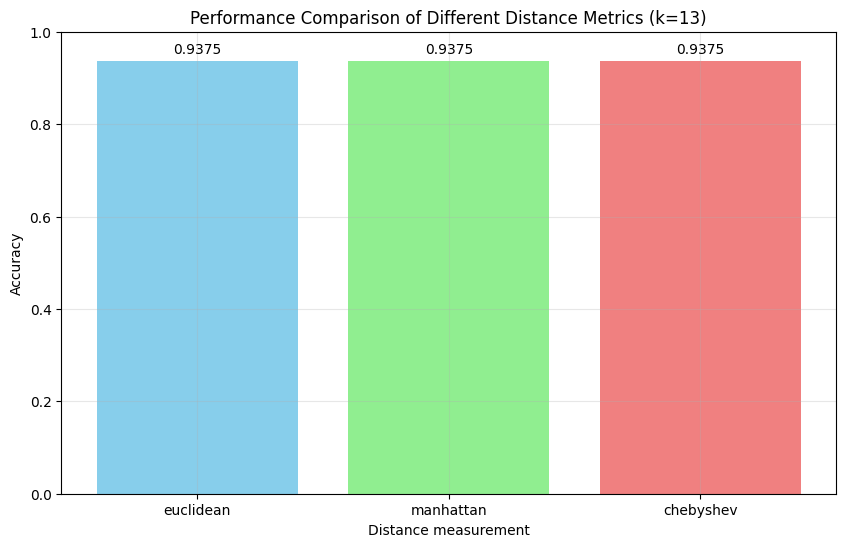


最佳距离度量: euclidean
最佳准确率: 0.9375


In [32]:
# 不同距离度量的比较
from sklearn.neighbors import KNeighborsClassifier

distance_metrics = ["euclidean", "manhattan", "chebyshev"]
distance_scores = {}

print("比较不同距离度量的性能:")
print("-" * 40)

for metric in distance_metrics:
    knn_metric = KNeighborsClassifier(n_neighbors=best_k, metric=metric)
    knn_metric.fit(X_train_scaled, y_train)
    y_pred_metric = knn_metric.predict(X_test_scaled)
    accuracy_metric = accuracy_score(y_test, y_pred_metric)
    distance_scores[metric] = accuracy_metric
    print(f"{metric:12} 距离: {accuracy_metric:.4f}")

# 可视化不同距离度量的比较
plt.figure(figsize=(10, 6))
metrics = list(distance_scores.keys())
scores = list(distance_scores.values())
bars = plt.bar(metrics, scores, color=["skyblue", "lightgreen", "lightcoral"])
plt.xlabel("Distance measurement")
plt.ylabel("Accuracy")
plt.title(f"Performance Comparison of Different Distance Metrics (k={best_k})")
plt.ylim(0, 1)

# 在柱状图上添加数值标签
for bar, score in zip(bars, scores):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{score:.4f}",
        ha="center",
        va="bottom",
    )

plt.grid(True, alpha=0.3)
plt.show()

print(f"\n最佳距离度量: {max(distance_scores, key=distance_scores.get)}")
print(f"最佳准确率: {max(distance_scores.values()):.4f}")

## KNN算法实现总结

### 完整流程回顾

#### 1. 数据探索和预处理
- **数据加载**: 使用pandas加载w3classif.csv数据集
- **数据分析**: 查看数据形状、分布、统计信息
- **数据可视化**: 绘制散点图和类别分布图
- **特征工程**: 分离特征和标签，进行训练测试分割
- **数据标准化**: 使用StandardScaler进行特征标准化

#### 2. KNN算法实现
- **从零实现**: 编写完整的KNN分类器类
  - 距离计算：欧几里得距离
  - 邻居选择：按距离排序选择k个最近邻
  - 投票机制：多数投票决定分类结果
- **scikit-learn实现**: 使用现成的KNeighborsClassifier进行对比

#### 3. 模型优化
- **k值调优**: 使用交叉验证寻找最佳k值
- **距离度量比较**: 比较欧几里得、曼哈顿、切比雪夫距离
- **性能评估**: 准确率、分类报告、混淆矩阵

#### 4. 结果可视化
- **决策边界**: 可视化分类器的决策边界
- **性能比较**: 图表展示不同参数的影响

### 关键发现

1. **数据预处理的重要性**: 标准化显著影响KNN的性能
2. **k值选择**: 通过交叉验证找到平衡偏差和方差的最佳k值
3. **距离度量**: 不同距离度量适用于不同类型的数据
4. **算法特点**: KNN是懒惰学习算法，计算复杂度在预测阶段

### KNN算法优缺点

#### 优点
- 简单易懂，无需假设数据分布
- 适用于多分类问题
- 对局部模式敏感，能处理复杂决策边界
- 新数据加入时无需重新训练

#### 缺点
- 计算复杂度高，预测速度慢
- 对高维数据效果不佳（维度诅咒）
- 对噪声和异常值敏感
- 需要选择合适的k值和距离度量